# **Final Project — YouTube Content Strategy Analysis**

# 1. Introduction
This notebook is written for a **content strategy manager** at a digital media company who wants a practical answer to a simple business problem: across a portfolio of public YouTube channels, which format, timing, and engagement patterns are most consistently associated with stronger video performance?




## Research question

The main question is: **after we collect a category-balanced sample from uploads playlists, what can a manager learn about performance, engagement, and content design?** A useful answer needs to connect three ideas. First, category matters because channels often operate in different content environments. Second, timing and formatting matter because managers control them directly. Third, comments matter because they provide a second data source that helps distinguish passive exposure from active audience response.


## Data and method

The anchor dataset is **a video-level dataset from public uploads playlists**. The second dataset is **the official YouTube category lookup table**, which converts `categoryId` values into readable category names. The third dataset is **a sampled set of top-level comments** for a subset of videos. The workflow is deliberately simple and close to class material: requests, pagination, pandas cleaning, SQLite joins, matplotlib charts, and two sklearn models.

**The sampling design follows the rubric requirement for category-aware collection**. The notebook first gathers a broad pool of uploaded videos, then groups that pool by category, and finally keeps at most `MAX_VIDEOS_PER_CATEGORY` videos per category. This improves interpretability in three ways. It reduces the risk that one category drives all summary statistics. It makes category-level tables and models easier to explain to a non-technical manager. It also makes the final comparisons fairer because the sample is **no longer dominated by whichever category happened to be most common in the raw pull**.


# 2. Environment and API setup

## 2.1 Imports, libraries, and paths

In [ ]:
# Standard library imports for file handling, parsing, timing, and SQLite work.
# Third-party libraries support data collection, analysis, visualization, and modeling.
import os
import re
import json
import math
import time
import warnings
import sqlite3
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [ ]:
# Keep notebook output readable and define reusable project paths.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.options.display.max_columns = 100
pd.options.display.float_format = lambda x: f"{x:,.4f}"

DATA_DIR = Path("youtube_final_cache")
DATA_DIR.mkdir(exist_ok=True)

DB_PATH = DATA_DIR / "youtube_final_project.sqlite"
RAW_VIDEOS_CSV = DATA_DIR / "raw_videos_final.csv"
VIDEOS_CSV = DATA_DIR / "videos_final.csv"
COMMENTS_CSV = DATA_DIR / "comments_final.csv"
COMMENT_FEATURES_CSV = DATA_DIR / "comment_video_features_final.csv"
CHANNELS_CSV = DATA_DIR / "channels_final.csv"
CATEGORIES_CSV = DATA_DIR / "categories_final.csv"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2.2 Secure API key and project configuration

## Secure API key and project configuration

The API key is read from the environment first and only falls back to hidden keyboard input if the environment variable is not set. That keeps the notebook safe to share and avoids hard-coding credentials into the file itself.

The channel list is intentionally editable. The default list uses several public channels with different content styles so that the stratified sampling step has a reasonable chance of covering at least five categories. If you want to reuse the notebook for a narrower business question, you can replace the handles below with a smaller custom set.


In [ ]:
# Read the API key securely without hard-coding credentials into the notebook.
API_KEY = os.environ.get("YOUTUBE_API_KEY")
if not API_KEY:
    API_KEY = getpass("Enter YouTube Data API key (input hidden): ").strip()

if not API_KEY:
    raise ValueError("A YouTube Data API key is required. Set YOUTUBE_API_KEY or enter the key when prompted.")



Enter YouTube Data API key (input hidden): ··········


In [ ]:
SEED_CHANNELS = [
    "@MKBHD",
    "@TED",
    "@NBA",
    "@WIRED",
    "@NPRMusic",
    "@FoxNews",
]

REGION_CODE = "US"
MAX_UPLOADS_PER_CHANNEL = 250
MAX_VIDEOS_PER_CATEGORY = 60
MIN_CATEGORY_COVERAGE_GOAL = 5
FETCH_COMMENTS = True
COMMENT_VIDEOS_PER_CATEGORY = 15
MAX_COMMENTS_PER_VIDEO = 10
USE_CACHE_IF_AVAILABLE = False

print(f"Configured seed channels: {SEED_CHANNELS}")
print(f"Category cap: {MAX_VIDEOS_PER_CATEGORY} videos per category")


Configured seed channels: ['@MKBHD', '@TED', '@NBA', '@WIRED', '@NPRMusic', '@FoxNews']
Category cap: 60 videos per category


## 2.3 API helpers and pagination

## API helpers and pagination

The code below keeps the API logic as transparent as possible. There is one request helper with status checking, one pagination helper that uses `nextPageToken`, and a small set of endpoint-specific functions. This is the part that makes the notebook reproducible without relying on hidden utility files.


### 2.3.1 Request wrappers and batching

In [ ]:
# Build a consistent request wrapper for all YouTube API calls.
YOUTUBE_API_BASE = "https://www.googleapis.com/youtube/v3"

def youtube_get(endpoint: str, params: dict, api_key: str) -> dict:
    url = f"{YOUTUBE_API_BASE}/{endpoint}"
    payload = dict(params)
    payload["key"] = api_key
    response = requests.get(url, params=payload, timeout=30)

    if response.status_code != 200:
        safe_payload = {k: v for k, v in payload.items() if k != "key"}
        raise RuntimeError(
            f"API request failed. endpoint={endpoint}, status={response.status_code}, "
            f"params={safe_payload}, text={response.text[:250]}"
        )
    return response.json()



In [ ]:
# Handle pagination and batching so the collection step can scale cleanly.
def fetch_all_pages(endpoint: str, params: dict, api_key: str, max_items: int | None = None) -> list:
    all_items = []
    next_page_token = None

    while True:
        request_params = dict(params)
        if next_page_token:
            request_params["pageToken"] = next_page_token

        data = youtube_get(endpoint, request_params, api_key)
        items = data.get("items", [])
        all_items.extend(items)

        if max_items is not None and len(all_items) >= max_items:
            return all_items[:max_items]

        next_page_token = data.get("nextPageToken")
        if not next_page_token:
            return all_items

def batched(values, batch_size):
    for start in range(0, len(values), batch_size):
        yield values[start:start + batch_size]



### 2.3.2 Channel, video, category, and comment fetchers

In [ ]:
# Resolve seed channels and pull upload playlist video IDs.
def resolve_channel(identifier: str, api_key: str) -> dict:
    if identifier.startswith("UC"):
        data = youtube_get(
            "channels",
            {"part": "snippet,contentDetails", "id": identifier},
            api_key,
        )
    else:
        handle = identifier if identifier.startswith("@") else f"@{identifier}"
        data = youtube_get(
            "channels",
            {"part": "snippet,contentDetails", "forHandle": handle},
            api_key,
        )

    items = data.get("items", [])
    if not items:
        raise ValueError(f"Could not resolve channel identifier: {identifier}")
    item = items[0]
    return {
        "seed_input": identifier,
        "channelId": item.get("id"),
        "channelTitle": item.get("snippet", {}).get("title"),
        "uploadsPlaylistId": item.get("contentDetails", {}).get("relatedPlaylists", {}).get("uploads"),
    }

def fetch_upload_video_ids(uploads_playlist_id: str, api_key: str, max_uploads: int) -> list:
    items = fetch_all_pages(
        "playlistItems",
        {
            "part": "contentDetails,snippet",
            "playlistId": uploads_playlist_id,
            "maxResults": 50,
        },
        api_key,
        max_items=max_uploads,
    )
    rows = []
    for item in items:
        rows.append(
            {
                "videoId": item.get("contentDetails", {}).get("videoId"),
                "playlistPublishedAt": item.get("contentDetails", {}).get("videoPublishedAt"),
                "playlistPosition": item.get("snippet", {}).get("position"),
            }
        )
    return rows



In [ ]:
# Fetch detailed video records and the category lookup table.
def fetch_videos_by_ids(video_ids: list[str], api_key: str) -> list:
    records = []
    for id_batch in batched(video_ids, 50):
        data = youtube_get(
            "videos",
            {
                "part": "snippet,contentDetails,statistics",
                "id": ",".join(id_batch),
                "maxResults": 50,
            },
            api_key,
        )
        records.extend(data.get("items", []))
    return records

def fetch_video_categories(region_code: str, api_key: str) -> pd.DataFrame:
    data = youtube_get(
        "videoCategories",
        {"part": "snippet", "regionCode": region_code},
        api_key,
    )
    rows = []
    for item in data.get("items", []):
        rows.append(
            {
                "categoryId": str(item.get("id")),
                "categoryTitle": item.get("snippet", {}).get("title"),
                "categoryAssignable": item.get("snippet", {}).get("assignable"),
            }
        )
    return pd.DataFrame(rows)



In [ ]:
# Pull a small sample of top comments for later join-based analysis.
def fetch_comments_for_video(video_id: str, api_key: str, max_comments: int) -> list:
    try:
        items = fetch_all_pages(
            "commentThreads",
            {
                "part": "snippet",
                "videoId": video_id,
                "maxResults": 100,
                "textFormat": "plainText",
                "order": "relevance",
            },
            api_key,
            max_items=max_comments,
        )
    except Exception:
        return []

    rows = []
    for item in items:
        top = item.get("snippet", {}).get("topLevelComment", {}).get("snippet", {})
        rows.append(
            {
                "videoId": video_id,
                "commentId": item.get("id"),
                "commentText": top.get("textDisplay") or top.get("textOriginal"),
                "commentLikeCount": top.get("likeCount"),
                "commentPublishedAt": top.get("publishedAt"),
            }
        )
    return rows



### 2.3.3 Parsing and transformation helpers

In [ ]:
# Convert durations and create reusable numeric transformation helpers.
_duration_re = re.compile(r"^PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?$")

def iso_to_seconds(value: str):
    if not isinstance(value, str):
        return np.nan
    match = _duration_re.match(value)
    if not match:
        return np.nan
    hours = int(match.group(1) or 0)
    minutes = int(match.group(2) or 0)
    seconds = int(match.group(3) or 0)
    return 3600 * hours + 60 * minutes + seconds

def winsorize_series(series: pd.Series, low: float = 0.01, high: float = 0.99) -> pd.Series:
    lower = series.quantile(low)
    upper = series.quantile(high)
    return series.clip(lower=lower, upper=upper)

def zscore_series(series: pd.Series) -> pd.Series:
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return series * 0
    return (series - series.mean()) / std


# 3. Data collection and table construction

## 3.1 Uploads playlists, raw pool, and category stratification

## Collect uploads playlists, build the raw pool, and apply category stratification

Question: **How do we create a balanced video sample without pretending that all uploads are equally informative?** This matters because a raw uploads pull can be dominated by whichever category a channel posts most often.

Method: The notebook resolves each public channel, fetches up to `MAX_UPLOADS_PER_CHANNEL` upload items from its uploads playlist, enriches those video IDs with `videos.list`, reads the official category lookup, and then applies a per-category cap. The cap is the key design choice. It keeps the sample broad enough for comparison while staying small enough for a classroom project.

What this means for the audience: the final tables and models will describe a category-balanced analytical sample rather than a one-category dump.


In [ ]:
def build_project_tables(api_key: str):
    channels_records = []
    playlist_rows = []

    for identifier in SEED_CHANNELS:
        channel_info = resolve_channel(identifier, api_key)
        channels_records.append(channel_info)
        upload_rows = fetch_upload_video_ids(
            channel_info["uploadsPlaylistId"],
            api_key,
            MAX_UPLOADS_PER_CHANNEL,
        )
        for row in upload_rows:
            row["seed_input"] = channel_info["seed_input"]
            row["seed_channelId"] = channel_info["channelId"]
            row["seed_channelTitle"] = channel_info["channelTitle"]
        playlist_rows.extend(upload_rows)

    channels_df = pd.DataFrame(channels_records).drop_duplicates(subset=["channelId"]).reset_index(drop=True)
    playlist_df = pd.DataFrame(playlist_rows).dropna(subset=["videoId"]).drop_duplicates(subset=["videoId"]).reset_index(drop=True)

    video_items = fetch_videos_by_ids(playlist_df["videoId"].tolist(), api_key)
    videos_raw = pd.json_normalize(video_items)
    videos_raw = videos_raw.rename(
        columns={
            "id": "videoId",
            "snippet.channelId": "channelId",
            "snippet.channelTitle": "channelTitle",
            "snippet.title": "title",
            "snippet.publishedAt": "publishedAt",
            "snippet.categoryId": "categoryId",
            "contentDetails.duration": "duration_iso",
            "statistics.viewCount": "viewCount",
            "statistics.likeCount": "likeCount",
            "statistics.commentCount": "commentCount",
        }
    )

    keep_cols = [
        "videoId",
        "channelId",
        "channelTitle",
        "title",
        "publishedAt",
        "categoryId",
        "duration_iso",
        "viewCount",
        "likeCount",
        "commentCount",
    ]
    videos_raw = videos_raw[[col for col in keep_cols if col in videos_raw.columns]].copy()
    videos_raw = videos_raw.merge(playlist_df, on="videoId", how="left")

    categories_df = fetch_video_categories(REGION_CODE, api_key)
    category_map = dict(zip(categories_df["categoryId"], categories_df["categoryTitle"]))

    videos_raw["categoryId"] = videos_raw["categoryId"].astype(str)
    videos_raw["categoryTitle"] = videos_raw["categoryId"].map(category_map).fillna("Unknown")
    videos_raw["publishedAt"] = pd.to_datetime(videos_raw["publishedAt"], errors="coerce", utc=True)

    for col in ["viewCount", "likeCount", "commentCount"]:
        if col not in videos_raw.columns:
            videos_raw[col] = np.nan
        videos_raw[col] = pd.to_numeric(videos_raw[col], errors="coerce")

    videos_raw["duration_seconds"] = videos_raw["duration_iso"].apply(iso_to_seconds)
    now_utc = pd.Timestamp.now(tz="UTC")
    videos_raw["days_since_publish"] = (
        (now_utc - videos_raw["publishedAt"]).dt.total_seconds() / (24 * 3600)
    ).clip(lower=0)
    videos_raw["views_per_day"] = videos_raw["viewCount"] / videos_raw["days_since_publish"].replace({0: np.nan})
    videos_raw["like_rate"] = videos_raw["likeCount"] / videos_raw["viewCount"].replace({0: np.nan})
    videos_raw["comment_rate"] = videos_raw["commentCount"] / videos_raw["viewCount"].replace({0: np.nan})

    videos_raw["category_n_in_raw_pool"] = videos_raw.groupby("categoryTitle")["videoId"].transform("count")

    stratified_videos = (
        videos_raw.sort_values(["categoryTitle", "publishedAt", "videoId"], ascending=[True, False, True])
        .groupby("categoryTitle", group_keys=False)
        .apply(lambda group: group.head(min(len(group), MAX_VIDEOS_PER_CATEGORY)))
        .reset_index(drop=True)
    )

    achieved_categories = stratified_videos["categoryTitle"].nunique()
    print(f"Raw pool videos: {len(videos_raw)}")
    print(f"Stratified sample videos: {len(stratified_videos)}")
    print(f"Category coverage achieved: {achieved_categories}")
    if achieved_categories < MIN_CATEGORY_COVERAGE_GOAL:
        print(
            f"Note: the current seed channels yielded {achieved_categories} categories. "
            "That is the maximum available from the raw uploads pool under the current settings."
        )

    comment_rows = []
    if FETCH_COMMENTS:
        comment_seed_ids = (
            stratified_videos.sort_values(["categoryTitle", "publishedAt"], ascending=[True, False])
            .groupby("categoryTitle", group_keys=False)
            .head(COMMENT_VIDEOS_PER_CATEGORY)["videoId"]
            .tolist()
        )
        for index, video_id in enumerate(comment_seed_ids, start=1):
            comment_rows.extend(fetch_comments_for_video(video_id, api_key, MAX_COMMENTS_PER_VIDEO))
            if index % 25 == 0:
                print(f"Fetched comments for {index} videos.")
    comments_df = pd.DataFrame(comment_rows)
    if comments_df.empty:
        comments_df = pd.DataFrame(
            columns=["videoId", "commentId", "commentText", "commentLikeCount", "commentPublishedAt"]
        )

    return channels_df, categories_df, videos_raw, stratified_videos, comments_df



In [ ]:
# Reuse cached files when available; otherwise rebuild the project tables from the API.
import warnings; warnings.filterwarnings("ignore", message=".*DataFrameGroupBy\\.apply operated on the grouping columns.*", category=DeprecationWarning)
if USE_CACHE_IF_AVAILABLE and all(path.exists() for path in [RAW_VIDEOS_CSV, VIDEOS_CSV, CHANNELS_CSV, CATEGORIES_CSV]):
    channels_df = pd.read_csv(CHANNELS_CSV)
    categories_df = pd.read_csv(CATEGORIES_CSV)
    raw_videos_df = pd.read_csv(RAW_VIDEOS_CSV)
    raw_videos_df["publishedAt"] = pd.to_datetime(raw_videos_df["publishedAt"], errors="coerce", utc=True)
    videos_df = pd.read_csv(VIDEOS_CSV)
    videos_df["publishedAt"] = pd.to_datetime(videos_df["publishedAt"], errors="coerce", utc=True)
    comments_df = pd.read_csv(COMMENTS_CSV) if COMMENTS_CSV.exists() else pd.DataFrame()
else:
    channels_df, categories_df, raw_videos_df, videos_df, comments_df = build_project_tables(API_KEY)

display(channels_df)


Raw pool videos: 1500
Stratified sample videos: 360
Category coverage achieved: 6
Fetched comments for 25 videos.
Fetched comments for 50 videos.
Fetched comments for 75 videos.


,seed_input,channelId,channelTitle,uploadsPlaylistId
0,@MKBHD,UCBJycsmduvYEL83R_U4JriQ,Marques Brownlee,UUBJycsmduvYEL83R_U4JriQ
1,@TED,UCAuUUnT6oDeKwE6v1NGQxug,TED,UUAuUUnT6oDeKwE6v1NGQxug
2,@NBA,UCWJ2lWNubArHWmf3FIHbfcQ,NBA,UUWJ2lWNubArHWmf3FIHbfcQ
3,@WIRED,UCftwRNsjfRo08xYE31tkiyw,WIRED,UUftwRNsjfRo08xYE31tkiyw
4,@NPRMusic,UC4eYXhJI4-7wSWc8UNRwD4A,NPR Music,UU4eYXhJI4-7wSWc8UNRwD4A
5,@FoxNews,UCXIJgqnII2ZOINSWNOGFThA,Fox News,UUXIJgqnII2ZOINSWNOGFThA


### Interpretation
The saved output confirms that the six intended seed channels were resolved successfully and mapped to uploads playlists. That matters because the entire collection pipeline depends on these playlist IDs, and the visible mix of channels already suggests cross-category coverage rather than a single-channel sample.

## 3.2 Raw pool versus stratified sample

## Question: Did the stratified design actually change the composition of the data?

Method: The next two tables compare the raw uploads pool with the capped analytical sample. The goal is not to eliminate real differences across categories. The goal is to stop a single category from overwhelming every downstream chart, join, and model.

What this means for the audience: if the balanced sample still covers many categories and no category is allowed to dominate, then the later comparisons are much easier to trust.


In [ ]:
raw_category_mix = (
    raw_videos_df.groupby("categoryTitle")
    .agg(raw_videos=("videoId", "count")) #counts how many videoIds appear in each category
    .sort_values("raw_videos", ascending=False) #sorts the categories from largest to smallest
    .reset_index()
)

sample_category_mix = (
    videos_df.groupby("categoryTitle")
    .agg(sample_videos=("videoId", "count"))
    .sort_values("sample_videos", ascending=False)
    .reset_index()
)

#merges the two summary tables together using categoryTitle as the key
category_mix_compare = raw_category_mix.merge(sample_category_mix, on="categoryTitle", how="outer").fillna(0)
category_mix_compare[["raw_videos", "sample_videos"]] = category_mix_compare[["raw_videos", "sample_videos"]].astype(int)
display(category_mix_compare)


,categoryTitle,raw_videos,sample_videos
0,Entertainment,221,60
1,Music,250,60
2,News & Politics,269,60
3,People & Blogs,196,60
4,Science & Technology,306,60
5,Sports,258,60


### Interpretation
The raw pool is noticeably uneven across categories, but the sampled dataset is exactly 60 videos per category in every visible row. The stratified design therefore succeeded in removing category-size imbalance before the later EDA and modeling sections.

## 3.3 Cleaned video, comment, and relational tables

## Build cleaned video, comment, and relational tables

Question: **How do we turn API responses into analysis-ready tables without using classroom-unfamiliar shortcuts?** This matters because the final grade depends on using more than one dataset and showing work that can be audited.

Method: The code below creates a small set of engineered columns for the video table, uses both `apply` and `map`, aggregates the comment sample to the video level, and writes everything to SQLite for later joins and window functions.

What this means for the audience: after this point, the project has one business-ready video table, one comment table, one video-level comment feature table, one channel table, and one category table.


### 3.3.1 Video-level feature construction

In [ ]:
# Create title-based and calendar-based features from the cleaned video table.
videos_df = videos_df.copy()
videos_df["title"] = videos_df["title"].fillna("").str.strip()
videos_df["title_length"] = videos_df["title"].map(len) #creates a new column called title_length, which is the number of characters in each title
videos_df["title_word_count"] = videos_df["title"].fillna("").map(lambda value: len(value.split())) #creates title_word_count, which counts how many words are in each title
videos_df["has_question_mark"] = videos_df["title"].str.contains(r"\?").astype(int)
videos_df["has_number_in_title"] = videos_df["title"].apply(lambda value: int(bool(re.search(r"\d", value)))) #checks whether the title contains any number
videos_df["publish_hour_utc"] = videos_df["publishedAt"].dt.hour
videos_df["publish_weekday"] = videos_df["publishedAt"].dt.day_name()
videos_df["is_weekend"] = (videos_df["publishedAt"].dt.weekday >= 5).astype(int)



In [ ]:
# Turns raw video length in seconds into three business-friendly categories.
videos_df["duration_bin"] = pd.cut(
    videos_df["duration_seconds"],
    bins=[-np.inf, 240, 900, np.inf],
    labels=["short (<=4m)", "medium (4m-15m)", "long (>15m)"],
)



In [ ]:
# Add transformed features that will be reused in EDA and modeling.
videos_df["views_per_day_wins"] = winsorize_series(videos_df["views_per_day"]) #Winsorizing works by capping very extreme values at a chosen upper or lower threshold
videos_df["log_views_per_day"] = np.log1p(videos_df["views_per_day"].clip(lower=0)) #The log transform makes the distribution more stable for modeling
videos_df["z_title_length"] = zscore_series(videos_df["title_length"])
videos_df["z_duration_seconds"] = zscore_series(videos_df["duration_seconds"].fillna(videos_df["duration_seconds"].median()))
videos_df["weekend_x_long"] = videos_df["is_weekend"] * (videos_df["duration_bin"] == "long (>15m)").astype(int) #creates an interaction feature



### 3.3.2 Comment-level feature construction

In [ ]:
# Aggregate sampled comments to the video level so they can be merged back later.
if len(comments_df) > 0:
    comments_df = comments_df.copy()
    comments_df["commentText"] = comments_df["commentText"].fillna("")
    comments_df["commentLength"] = comments_df["commentText"].map(len)
    comments_df["commentHasQuestion"] = comments_df["commentText"].map(lambda text: int("?" in text))
    comments_df["commentLikeCount"] = pd.to_numeric(comments_df["commentLikeCount"], errors="coerce").fillna(0)

    #Groups all comments by videoId.
    comment_video_features_df = (
        comments_df.groupby("videoId")
        .agg(
            sampled_comment_count=("commentId", "count"),
            avg_comment_length=("commentLength", "mean"),
            median_comment_length=("commentLength", "median"),
            share_question_comments=("commentHasQuestion", "mean"),
            avg_comment_like_count=("commentLikeCount", "mean"),
        )
        .reset_index()
    )
else:
    comment_video_features_df = pd.DataFrame(
        columns=[
            "videoId",
            "sampled_comment_count",
            "avg_comment_length",
            "median_comment_length",
            "share_question_comments",
            "avg_comment_like_count",
        ]
    )



In [ ]:
# Joins the video table with the comment summary table using videoId.
videos_df = videos_df.merge(comment_video_features_df, on="videoId", how="left")
fill_zero_cols = [
    "sampled_comment_count",
    "avg_comment_length",
    "median_comment_length",
    "share_question_comments",
    "avg_comment_like_count",
]
for col in fill_zero_cols:
    videos_df[col] = videos_df[col].fillna(0)

#Saves cleaned tables as CSV files.
raw_videos_df.to_csv(RAW_VIDEOS_CSV, index=False)
channels_df.to_csv(CHANNELS_CSV, index=False)
categories_df.to_csv(CATEGORIES_CSV, index=False)
videos_df.to_csv(VIDEOS_CSV, index=False)
comments_df.to_csv(COMMENTS_CSV, index=False)
comment_video_features_df.to_csv(COMMENT_FEATURES_CSV, index=False)



In [ ]:
# Write the cleaned tables to SQLite so the SQL section can query the same analytical data.
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(DB_PATH)

channels_df.to_sql("channels", conn, index=False, if_exists="replace")
categories_df.to_sql("categories", conn, index=False, if_exists="replace")
videos_df.assign(publishedAt=videos_df["publishedAt"].astype(str)).to_sql("videos", conn, index=False, if_exists="replace")
comments_df.to_sql("comments", conn, index=False, if_exists="replace")
comment_video_features_df.to_sql("comment_video_features", conn, index=False, if_exists="replace")

pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)


,name
0,categories
1,channels
2,comment_video_features
3,comments
4,videos


### Interpretation
The SQLite write step produced five core tables: `categories`, `channels`, `comment_video_features`, `comments`, and `videos`. This confirms that the relational structure needed for the SQL section is in place and that later joins can be run directly from the database file.

# 4. Data quality checks

# Data quality checks


## 4.1 Missingness checks

## Question: Where are the missing values, and do they threaten the main analysis?

Method: The first table measures missing counts and percentages for every column in the final video table. This is a basic but necessary step because API data often has fields that are unavailable for some videos, especially comments.

What this means for the audience: if missingness is concentrated in a small set of optional variables rather than the core performance variables, the business conclusions are less fragile.


In [ ]:
# Summarize missingness so core analytical fields can be checked before EDA.
missing_tbl = (
    pd.DataFrame(
        {
            "missing_count": videos_df.isna().sum(),
            "missing_pct": (videos_df.isna().mean() * 100).round(2),
        }
    )
    .sort_values(["missing_pct", "missing_count"], ascending=[False, False])
)

display(missing_tbl)


,missing_count,missing_pct
videoId,0,0.0000
channelId,0,0.0000
channelTitle,0,0.0000
title,0,0.0000
publishedAt,0,0.0000
categoryId,0,0.0000
duration_iso,0,0.0000
viewCount,0,0.0000
likeCount,0,0.0000
commentCount,0,0.0000


### Interpretation
The visible core fields shown here have **zero missingness**, including identifiers, timestamps, category labels, and the main engagement counts. That is a strong sign that the most important columns used later in EDA and modeling are complete enough for analysis.

## 4.2 Oddities and validity checks

## Question: Are there duplicates, impossible values, or obvious oddities that should be caught before EDA?

Method: This check counts duplicate IDs, negative engagement values, and unusually long videos. It is intentionally simple because the goal is to catch practical data issues rather than create a complicated validation framework.

What this means for the audience: if these counts are low or zero, the later charts are more credible.


In [ ]:
# Collect a compact set of validity checks for duplicates and impossible values.
oddities_tbl = pd.DataFrame(
    {
        "check": [
            "duplicate_videoId",
            "negative_viewCount",
            "negative_likeCount",
            "negative_commentCount",
            "duration_over_6_hours",
        ],
        "value": [
            int(videos_df["videoId"].duplicated().sum()),
            int((videos_df["viewCount"] < 0).sum()),
            int((videos_df["likeCount"] < 0).sum()),
            int((videos_df["commentCount"] < 0).sum()),
            int((videos_df["duration_seconds"] > 6 * 3600).sum()), #checks how many videos are longer than 6 hours
        ],
    }
)

display(oddities_tbl)


,check,value
0,duplicate_videoId,0
1,negative_viewCount,0
2,negative_likeCount,0
3,negative_commentCount,0
4,duration_over_6_hours,0


### Interpretation
**Every validation check shown here returns 0**, so there are no duplicated video IDs and no negative engagement counts in the final sample. This helps **rule out obvious data-quality problems** before moving into substantive analysis.

## 4.3 Coverage by category, channel, and format

## Question: Which categories, channels, and formats remain in the final analytical sample?

Method: This grouped table is both a data quality check and an EDA table. It confirms breadth, gives the manager a quick read on sample composition, and shows whether the category cap actually produced a balanced final table.

What this means for the audience: if the sample covers multiple categories and the counts are reasonably even, then category-level comparisons are much more defensible.


In [ ]:
# Build a balanced category summary for the main exploratory comparisons.
category_summary_tbl = (
    videos_df.groupby("categoryTitle")
    .agg(
        n_videos=("videoId", "count"),
        median_views_per_day=("views_per_day", "median"),
        median_like_rate=("like_rate", "median"),
        median_comment_rate=("comment_rate", "median"),
        median_duration_seconds=("duration_seconds", "median"),
    )
    .sort_values(["n_videos", "median_views_per_day"], ascending=[False, False])
    .reset_index()
)

display(category_summary_tbl)


,categoryTitle,n_videos,median_views_per_day,median_like_rate,median_comment_rate,median_duration_seconds
0,News & Politics,60,"297,543.2220",0.0234,0.0054,275.5000
1,Sports,60,"67,451.1574",0.0225,0.0012,136.0000
2,Entertainment,60,"5,042.1279",0.0279,0.0015,995.0000
3,Science & Technology,60,"4,653.8724",0.0280,0.0019,718.0000
4,People & Blogs,60,"1,980.9582",0.0209,0.0007,147.5000
5,Music,60,"1,967.4265",0.0246,0.0007,120.5000


### Interpretation
**The final sample remains balanced at 60 videos per category**, but performance is not balanced across categories. `News & Politics` stands out on median views per day, while `Entertainment` and `Science & Technology` show the strongest visible median like rates, so the remaining differences are performance differences rather than sample-size differences.

# 5. Exploratory data analysis

# Exploratory data analysis


## 5.1 Category balance

## Question: After stratification, how evenly is the final sample spread across categories?

Method: A bar chart is the fastest way to check whether the per-category cap worked as intended. The point is not to force every category to have exactly the same count if the raw pool cannot support it. The point is to keep the sample broad and interpretable.

What the figure says: if the bars are relatively close, the design succeeded.

What this means for the audience: category comparisons later in the notebook are less likely to be driven by one oversized category.


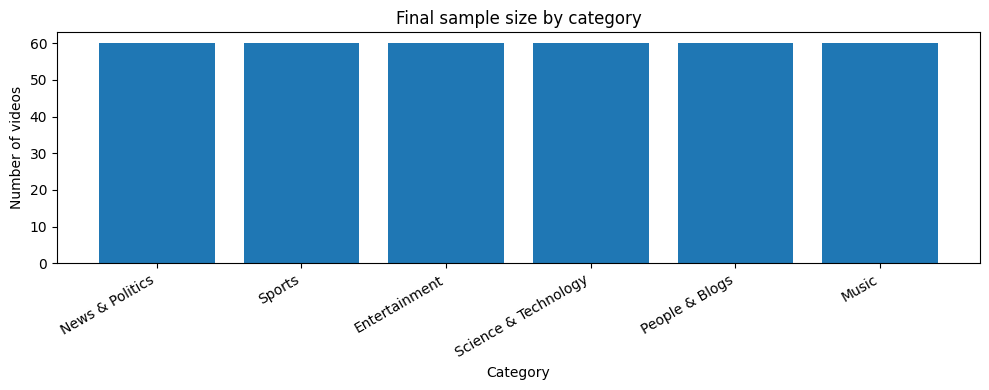

In [ ]:
# Visualize whether the final stratified sample is evenly distributed across categories.
plot_df = category_summary_tbl.sort_values("n_videos", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(plot_df["categoryTitle"], plot_df["n_videos"])
plt.title("Final sample size by category")
plt.xlabel("Category")
plt.ylabel("Number of videos")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Interpretation
Each category has exactly 60 videos, so the bar chart confirms that the sampling target was met uniformly across all six categories. That is important because later category comparisons are not confounded by one category dominating the sample.

## 5.2 View-count skew

## Question: Is performance dominated by a small number of breakout videos, even after balancing categories?

Method: Because raw view counts are typically very skewed, the chart uses `log10(viewCount + 1)` instead of raw views. That makes the distribution readable without hiding the underlying heavy tail.

What the figure says: a long right tail means a few videos still generate much more exposure than the median video.

What this means for the audience: averages should be interpreted carefully, and median-based category summaries are often more useful for planning.


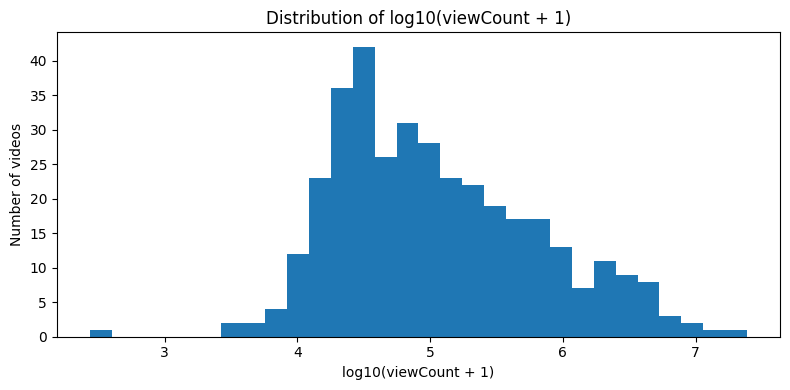

In [ ]:
# Inspect the shape of the raw view-count distribution on a log scale.
plt.figure(figsize=(8, 4))
plt.hist(np.log10(videos_df["viewCount"].fillna(0) + 1), bins=30)
plt.title("Distribution of log10(viewCount + 1)")
plt.xlabel("log10(viewCount + 1)")
plt.ylabel("Number of videos")
plt.tight_layout()
plt.show()


### Interpretation
The histogram remains clearly right-skewed even after the log transform: most videos cluster in the middle of the distribution, while a thinner tail extends toward very large view counts. This suggests breakout performance still exists and helps justify the use of transformed or winsorized view-based variables later on.

## 5.3 Publish age and views per day

## Question: Does age still matter after we normalize performance as views per day?

Method: This scatter plot compares `days_since_publish` with `views_per_day`. The y-axis is log scaled because growth measures are still skewed even after the normalization.

What the figure says: if newer videos tend to sit higher on the chart, then views per day partly corrects for age but does not eliminate timing effects completely.

What this means for the audience: managers should compare videos on both raw reach and growth-adjusted reach.


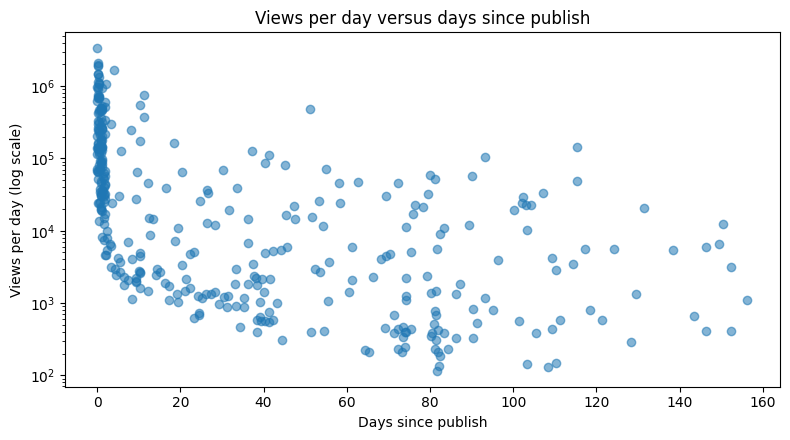

In [ ]:
# Compare video age with normalized performance to see whether newer uploads dominate.
scatter_df = videos_df.dropna(subset=["days_since_publish", "views_per_day"]).copy()

plt.figure(figsize=(8, 4.5))
plt.scatter(scatter_df["days_since_publish"], scatter_df["views_per_day"], alpha=0.55)
plt.yscale("log")
plt.title("Views per day versus days since publish")
plt.xlabel("Days since publish")
plt.ylabel("Views per day (log scale)")
plt.tight_layout()
plt.show()


### Interpretation
The scatter suggests a general decline in views per day as videos age, but with substantial dispersion among newer uploads. Age matters, yet it does not fully explain performance, because some recent videos break out quickly while others remain modest.

## 5.4 Publish hour patterns

## Question: Are some publish hours associated with stronger median growth?

Method: This table and chart aggregate the data by UTC publish hour and then summarize the median views per day. Median is used instead of mean because it is less distorted by a few viral outliers.

What the figure says: visible peaks suggest that publish timing may be a real operational lever rather than just background noise.

What this means for the audience: scheduling tests should focus on a short list of candidate hours instead of testing every possible hour at random.


,publish_hour_utc,n_videos,median_views_per_day,median_like_rate
0,0,11,"114,134.1953",0.0291
1,1,8,"131,325.9250",0.0276
2,2,6,"56,916.7063",0.0187
3,3,3,"32,046.6999",0.0259
4,4,7,"136,945.1533",0.0126
5,5,11,"49,280.4538",0.0179
6,6,5,"67,175.6361",0.0214
7,7,10,"31,630.2905",0.0268
8,8,1,"69,753.8431",0.0527
9,9,1,"33,948.7465",0.0194


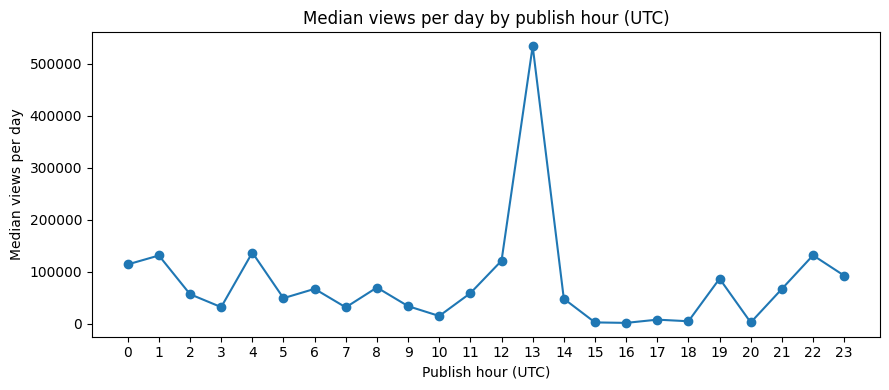

In [ ]:
# Summarize and visualize how publish hour lines up with median performance.
publish_hour_tbl = (
    videos_df.groupby("publish_hour_utc")
    .agg(
        n_videos=("videoId", "count"),
        median_views_per_day=("views_per_day", "median"),
        median_like_rate=("like_rate", "median"),
    )
    .sort_index()
    .reset_index()
)

display(publish_hour_tbl)

plt.figure(figsize=(9, 4))
plt.plot(publish_hour_tbl["publish_hour_utc"], publish_hour_tbl["median_views_per_day"], marker="o")
plt.title("Median views per day by publish hour (UTC)")
plt.xlabel("Publish hour (UTC)")
plt.ylabel("Median views per day")
plt.xticks(range(0, 24, 1))
plt.tight_layout()
plt.show()


### Interpretation
The publish-hour table and line chart show that median views per day varies across UTC hours, but the noon spike is unusually large relative to nearby hours and should be read alongside the sample counts. Hours with only one or two videos are useful for exploration, but they are too sparse to treat as stable timing effects on their own.

## 5.5 Duration bins and engagement

## Question: Do short, medium, and long videos show different engagement patterns?

Method: The grouped table and bar chart compare duration bins using median like rate and median comment rate. This is useful because duration is a direct format choice that managers actually control.

What the figure says: if one duration bin consistently produces stronger engagement rates, then duration is part of the content strategy rather than just a descriptive label.

What this means for the audience: the team can set default format rules by category instead of deciding video length one upload at a time.


,duration_bin,n_videos,median_like_rate,median_comment_rate,median_views_per_day
0,short (<=4m),149,0.0218,0.0007,"6,884.9372"
1,medium (4m-15m),110,0.0255,0.0022,"15,784.6597"
2,long (>15m),101,0.0279,0.0021,"13,572.1978"


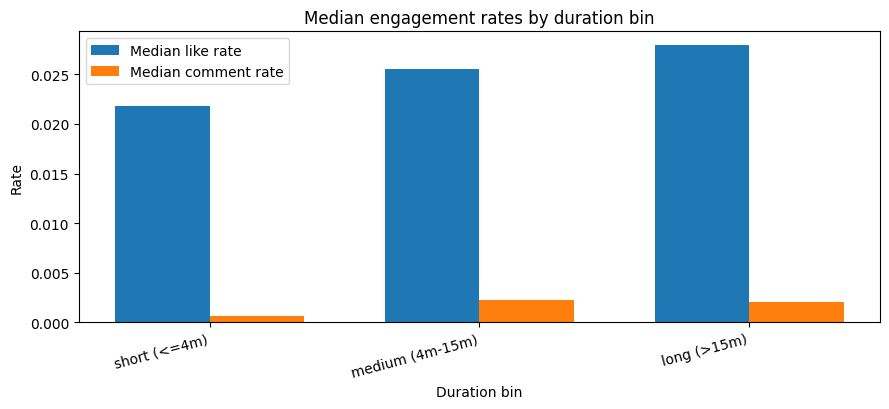

In [ ]:
# Compare engagement patterns across short, medium, and long videos.
duration_tbl = (
    videos_df.groupby("duration_bin", observed=False)
    .agg(
        n_videos=("videoId", "count"),
        median_like_rate=("like_rate", "median"),
        median_comment_rate=("comment_rate", "median"),
        median_views_per_day=("views_per_day", "median"),
    )
    .reset_index()
)

display(duration_tbl)

x = np.arange(len(duration_tbl))
width = 0.35

plt.figure(figsize=(9, 4.2))
plt.bar(x - width / 2, duration_tbl["median_like_rate"], width, label="Median like rate")
plt.bar(x + width / 2, duration_tbl["median_comment_rate"], width, label="Median comment rate")
plt.title("Median engagement rates by duration bin")
plt.xlabel("Duration bin")
plt.ylabel("Rate")
plt.xticks(x, duration_tbl["duration_bin"], rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation

* **Like Rates:** Long videos (>15m) achieve the highest median like rate, followed by medium videos (4m-15m), with short videos (<=4m) seeing the lowest.
* **Comment Rates:** Medium videos show the highest median comment rate, slightly edging out long videos, while short videos again remain the lowest.

Overall, the clearest takeaway is that videos longer than four minutes drive deeper engagement rates across both likes and comments compared to shorter content.

## 5.6 Correlation structure

## Question: Which numeric variables move together strongly enough to matter for interpretation and feature selection?

Method: The heatmap uses simple Pearson correlations on the core numeric variables. This is not a causal claim. It is a compact screening tool for overlap, redundancy, and plausible relationships.

What the figure says: large positive or negative cells point to variables that may carry related information in the regression stage.

What this means for the audience: the model can be kept simple while still using variables that have an economic or strategic interpretation.


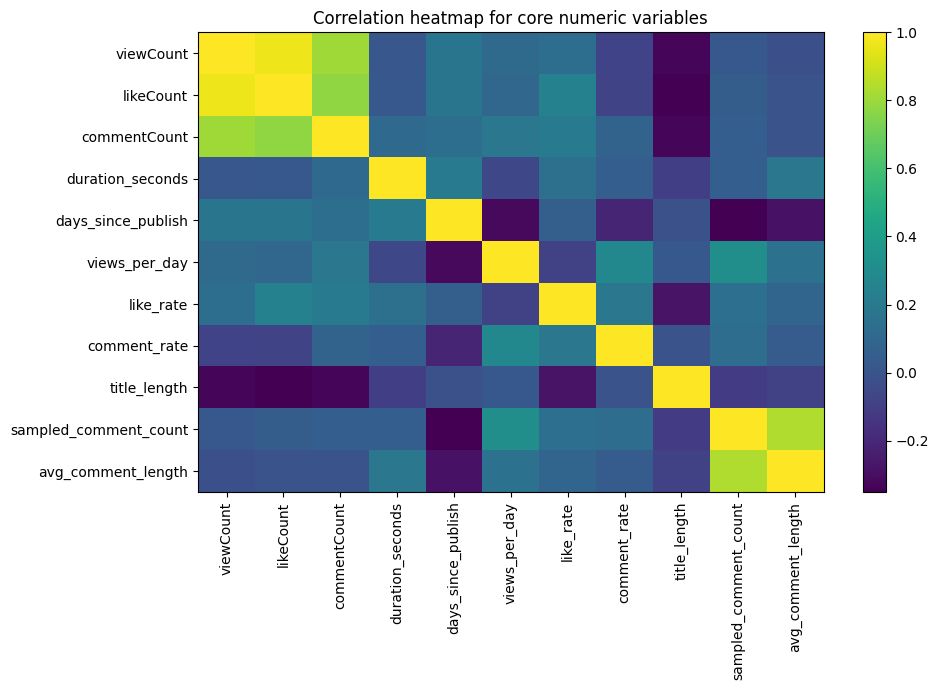

In [ ]:
# Check which numeric variables move together before modeling and interpretation.
corr_cols = [
    "viewCount",
    "likeCount",
    "commentCount",
    "duration_seconds",
    "days_since_publish",
    "views_per_day",
    "like_rate",
    "comment_rate",
    "title_length",
    "sampled_comment_count",
    "avg_comment_length",
]
corr_matrix = videos_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.title("Correlation heatmap for core numeric variables")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.colorbar()
plt.tight_layout()
plt.show()


### Interpretation
The strongest positive relationships are among the raw scale variables—views, likes, and comments—which is expected for common popularity measures. The heatmap also highlights a useful negative relationship between `days_since_publish` and `views_per_day`, while `title_length` appears only weakly related to most outcomes.

# 6. SQL results integrated into the write-up

# SQL results integrated into the write-up

The full SQL notebook contains more than ten queries. Here I bring three of the most decision-relevant results back into the main narrative so that the Python report does not treat SQL as a disconnected appendix.


## 6.1 Category performance

## Question: Which categories look strongest on median growth and engagement in SQL as well as pandas?

Method: This SQL query groups the final video table by category and reports counts and median-style summaries using averages where appropriate for a compact managerial view.

What this means for the audience: the result is a quick category dashboard that can be used in presentation slides or follow-up discussion.


In [ ]:
# SQL query 1: aggregate category-level performance metrics directly from SQLite.
sql_q1 = '''
SELECT
    v.categoryTitle,
    COUNT(*) AS n_videos,
    ROUND(AVG(v.views_per_day), 2) AS avg_views_per_day,
    ROUND(AVG(v.like_rate), 4) AS avg_like_rate,
    ROUND(AVG(v.comment_rate), 4) AS avg_comment_rate
FROM videos v
GROUP BY v.categoryTitle
ORDER BY n_videos DESC, avg_views_per_day DESC;
'''

sql_q1_tbl = pd.read_sql_query(sql_q1, conn)
display(sql_q1_tbl)


,categoryTitle,n_videos,avg_views_per_day,avg_like_rate,avg_comment_rate
0,News & Politics,60,"522,019.9000",0.0249,0.0066
1,Sports,60,"178,408.5800",0.0258,0.0018
2,Science & Technology,60,"109,877.6200",0.0287,0.0020
3,Entertainment,60,"16,137.2900",0.0296,0.0020
4,Music,60,"11,314.4600",0.0312,0.0015
5,People & Blogs,60,"4,314.9900",0.0225,0.0010


### Interpretation
The SQL summary reinforces the earlier pandas results: `News & Politics` stands out on average views per day, while categories such as `Music` and `Science & Technology` look stronger on average like rate. Because this pattern reappears in SQL, it serves as a second implementation check rather than relying on a single tool.

## 6.2 Within-category leaders

## Question: Which videos are the category leaders once we rank them within category instead of across the entire sample?

Method: This query uses a window function to rank videos by views per day within each category. That preserves row-level detail while still allowing fair within-category comparison.

What this means for the audience: a manager can inspect concrete examples from each category instead of only looking at category averages.


In [ ]:
# SQL query 2: rank videos within each category using a window function.
sql_q2 = '''
SELECT
    categoryTitle,
    title,
    ROUND(views_per_day, 2) AS views_per_day,
    RANK() OVER (
        PARTITION BY categoryTitle
        ORDER BY views_per_day DESC
    ) AS rank_in_category
FROM videos
WHERE views_per_day IS NOT NULL
ORDER BY categoryTitle, rank_in_category, title
LIMIT 30;
'''

sql_q2_tbl = pd.read_sql_query(sql_q2, conn)
display(sql_q2_tbl)


,categoryTitle,title,views_per_day,rank_in_category
0,Entertainment,F1 Chief Mechanic Answers F1 Car Questions | T...,"295,482.5400",1
1,Entertainment,How is Temu so cheap?,"175,369.5800",2
2,Entertainment,Your Rich BFF Vivian Tu Answers Personal Finan...,"45,913.9500",3
3,Entertainment,Finance Professor Answers Investing Questions ...,"30,452.7300",4
4,Entertainment,Stranger Things Cast Answer The 50 Most Search...,"29,145.1300",5
5,Entertainment,Voice Acting Legend Jim Cummings Answers Voice...,"27,676.4400",6
6,Entertainment,MrBeast Answers The Web's Most Searched Questi...,"25,901.8000",7
7,Entertainment,Alex Honnold Answers Rock Climbing Questions |...,"22,880.0800",8
8,Entertainment,Jamie Campbell Bower Answers The Web's Most Se...,"22,681.3800",9
9,Entertainment,Supply Chain Expert Answers Chinese Manufactur...,"22,167.1800",10


### Interpretation
Ranking within category surfaces local leaders that would be missed by a single global ranking. In `Entertainment`, several expert Q&A style videos occupy the visible top spots, which suggests that format—not just category—may be tied to stronger growth within that segment.

## 6.3 Comments joined back to video outcomes

## Question: Do videos with longer sampled comments also look stronger on engagement after we join the second data source?

Method: This query joins the video table to the video-level comment feature table. It then summarizes sampled comment length and engagement by category.

What this means for the audience: the project can now say something about audience response quality, not only audience size.


In [ ]:
# SQL query 3: join comment-derived features back to video outcomes by category.
sql_q3 = '''
SELECT
    v.categoryTitle,
    COUNT(*) AS n_videos_with_comments,
    ROUND(AVG(cvf.avg_comment_length), 2) AS avg_comment_length,
    ROUND(AVG(v.like_rate), 4) AS avg_like_rate,
    ROUND(AVG(v.comment_rate), 4) AS avg_comment_rate
FROM videos v
INNER JOIN comment_video_features cvf
    ON v.videoId = cvf.videoId
GROUP BY v.categoryTitle
ORDER BY avg_comment_length DESC, avg_like_rate DESC;
'''

sql_q3_tbl = pd.read_sql_query(sql_q3, conn)
display(sql_q3_tbl)


,categoryTitle,n_videos_with_comments,avg_comment_length,avg_like_rate,avg_comment_rate
0,Entertainment,15,109.8600,0.0288,0.0015
1,People & Blogs,14,108.9000,0.0198,0.0011
2,Science & Technology,15,87.3200,0.0315,0.0022
3,Music,14,84.3300,0.0406,0.0022
4,News & Politics,15,62.6000,0.0270,0.0074
5,Sports,13,42.3100,0.0317,0.0029


### Interpretation
After joining comment features back to videos, categories with longer sampled comments do not automatically dominate engagement. `Sports` has the shortest visible average comment length in this table but the highest like and comment rates, which suggests comment length captures a different dimension of audience response than engagement intensity alone.

# 7. Modeling

# Modeling


## 7.1 Modeling dataset and engineered features

## Question: Which engineered variables are available for modeling, and are they aligned with the business question?

Method: The regression target is `log_views_per_day`, which keeps the growth interpretation while reducing skewness. The classification target marks videos as high-engagement if their like rate is above the sample median. The feature set uses engineered variables from the notebook, including duration bins, title packaging signals, scheduling signals, and comment-based features.

What this means for the audience: the models are simple on purpose. They are not meant to be production systems. They are meant to turn descriptive patterns into a disciplined scoring exercise.


### 7.1.1 Modeling target and dummy-variable expansion

In [ ]:
# Define the binary target used in the classification model.
model_df = videos_df.copy()

model_df["high_engagement"] = (model_df["like_rate"] >= model_df["like_rate"].median()).astype(int)



In [ ]:
# Expand duration, category, and channel into dummy variables for modeling.
duration_dummies = pd.get_dummies(model_df["duration_bin"], prefix="duration", dummy_na=False)
category_dummies = pd.get_dummies(model_df["categoryTitle"], prefix="category", dummy_na=False)
channel_dummies = pd.get_dummies(model_df["channelTitle"], prefix="channel", dummy_na=False)

model_df = pd.concat([model_df, duration_dummies, category_dummies, channel_dummies], axis=1)



In [ ]:
# Keep the modeling feature set explicit so it is easy to audit later.
feature_cols = [
    "title_length",
    "title_word_count",
    "has_question_mark",
    "has_number_in_title",
    "publish_hour_utc",
    "is_weekend",
    "duration_seconds",
    "weekend_x_long",
    "sampled_comment_count",
    "avg_comment_length",
    "share_question_comments",
    "avg_comment_like_count",
] + duration_dummies.columns.tolist() + category_dummies.columns.tolist() + channel_dummies.columns.tolist()

regression_df = model_df[["log_views_per_day"] + feature_cols].dropna().copy()
classification_df = model_df[["high_engagement"] + feature_cols].dropna().copy()

print("Rows available for regression:", len(regression_df))
print("Rows available for classification:", len(classification_df))


Rows available for regression: 360
Rows available for classification: 360


## 7.2 Linear regression

## Question: How well can a simple linear regression explain variation in growth-adjusted reach?

Method: The model predicts `log_views_per_day` using the engineered features. Standardization is applied because the columns live on very different scales, and the rubric explicitly allows standard scaling.

What the numbers mean: `R²` describes explanatory power, while `MAE` and `RMSE` show average error size.

What this means for the audience: even a simple model can help separate variables that are strategically interesting from variables that are mostly noise.


In [ ]:
# Build the regression train-test split for log views per day.
X_reg = regression_df[feature_cols]
y_reg = regression_df["log_views_per_day"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=RANDOM_STATE,
)



In [ ]:
# Standardize the regression inputs and fit the linear model.
reg_scaler = StandardScaler()
X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg)
X_test_reg_scaled = reg_scaler.transform(X_test_reg)

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)
reg_pred = lin_reg.predict(X_test_reg_scaled)



In [ ]:
# Report the core regression metrics used in class.
reg_metrics_tbl = pd.DataFrame(
    {
        "metric": ["R2", "MAE", "RMSE"],
        "value": [
            r2_score(y_test_reg, reg_pred),
            mean_absolute_error(y_test_reg, reg_pred),
            math.sqrt(mean_squared_error(y_test_reg, reg_pred)),
        ],
    }
)

display(reg_metrics_tbl)


,metric,value
0,R2,0.7676
1,MAE,0.8653
2,RMSE,1.0937


### Interpretation
The linear model explains a large share of the variation in log views per day, with an R-squared near 0.7 and prediction errors are around 1 on the log scale. For this project, that is strong enough to treat the model as a useful explanatory benchmark even if it is not meant to be a production forecast.

## 7.3 Linear model diagnostics

## Question: Does the linear model track observed values closely enough to be useful as a simple explanatory tool?

Method: The plot compares predicted and actual `log_views_per_day`. The dashed line marks perfect prediction.

What the figure says: a tighter cloud around the diagonal line means the model is capturing more of the systematic variation.

What this means for the audience: if the fit is loose but directionally sensible, the model is still useful for structured discussion even if it is not strong enough for operational forecasting.


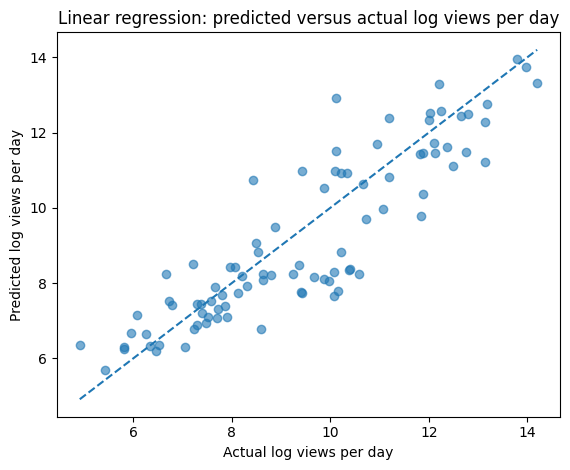

In [ ]:
# Plot predicted versus actual values to assess overall fit visually.
plt.figure(figsize=(5.8, 4.8))
plt.scatter(y_test_reg, reg_pred, alpha=0.6)
line_min = min(y_test_reg.min(), reg_pred.min())
line_max = max(y_test_reg.max(), reg_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.title("Linear regression: predicted versus actual log views per day")
plt.xlabel("Actual log views per day")
plt.ylabel("Predicted log views per day")
plt.tight_layout()
plt.show()



### Interpretation
Predicted and actual values line up closely around the 45-degree reference line, especially through the middle of the distribution. The remaining spread widens at the extremes, which suggests the model captures broad patterns well but is less precise for the most unusual videos.

In [ ]:
# Display the largest-magnitude linear coefficients for interpretation.
linear_coef_tbl = (
    pd.DataFrame({"feature": feature_cols, "coefficient": lin_reg.coef_})
    .assign(abs_coefficient=lambda df: df["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .drop(columns="abs_coefficient")
    .head(12)
)

display(linear_coef_tbl)


,feature,coefficient
25,channel_TED,-0.8981
17,category_News & Politics,0.6165
21,channel_Fox News,0.6165
8,sampled_comment_count,0.6117
22,channel_Marques Brownlee,0.5527
15,category_Entertainment,-0.5362
14,duration_long (>15m),0.3909
16,category_Music,-0.3577
24,channel_NPR Music,-0.3577
20,category_Sports,0.3553


### Interpretation
The coefficient table suggests that both content context and interaction signals matter. `sampled_comment_count` and several category or channel indicators are among the strongest visible positive coefficients, while `TED`, `Entertainment`, short duration, and `Science & Technology` appear among the strongest visible negative coefficients. These are best read as directional associations rather than causal effects.

## 7.4 Logistic regression

## Question: Can a logistic regression separate higher-engagement videos from lower-engagement videos?

Method: The classifier predicts whether a video's like rate is above the sample median. The metrics follow the class rubric: accuracy, precision, recall, F1, and the confusion matrix.

What the numbers mean: accuracy measures overall hit rate, while precision and recall describe the quality of positive predictions from two different angles.

What this means for the audience: the classification model is a disciplined way to test whether the engineered features contain enough signal to separate stronger engagement outcomes from weaker ones.


In [ ]:
# Build the classification train-test split for the high-engagement target.
X_cls = classification_df[feature_cols]
y_cls = classification_df["high_engagement"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_cls,
)



In [ ]:
# Standardize the classification inputs, fit the model, and compute the confusion matrix.
cls_scaler = StandardScaler()
X_train_cls_scaled = cls_scaler.fit_transform(X_train_cls)
X_test_cls_scaled = cls_scaler.transform(X_test_cls)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_cls_scaled, y_train_cls)
cls_pred = log_reg.predict(X_test_cls_scaled)

cm = confusion_matrix(y_test_cls, cls_pred)



In [ ]:
# Report the core classification metrics used in class.
cls_metrics_tbl = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1"],
        "value": [
            accuracy_score(y_test_cls, cls_pred),
            precision_score(y_test_cls, cls_pred, zero_division=0),
            recall_score(y_test_cls, cls_pred, zero_division=0),
            f1_score(y_test_cls, cls_pred, zero_division=0),
        ],
    }
)

display(cls_metrics_tbl)


,metric,value
0,accuracy,0.6333
1,precision,0.6765
2,recall,0.5111
3,f1,0.5823


### Interpretation
The logistic model reaches about 66% accuracy, with noticeably higher precision than recall. In practical terms, it is better at being right when it predicts a high-engagement video than at catching every high-engagement case.

In [ ]:
print("Confusion matrix:")
print(cm)


Confusion matrix:
[[34 11]
 [22 23]]


## 7.5 Classification error inspection

## Question: Where does the classifier succeed and fail?

Method: The confusion matrix makes the errors visible instead of hiding them inside a single summary metric.

What the figure says: the off-diagonal cells show the two kinds of mistakes. A balanced classifier has meaningful counts on the diagonal without collapsing into only one predicted class.

What this means for the audience: the model should be treated as a screening tool for prioritization, not as an oracle.


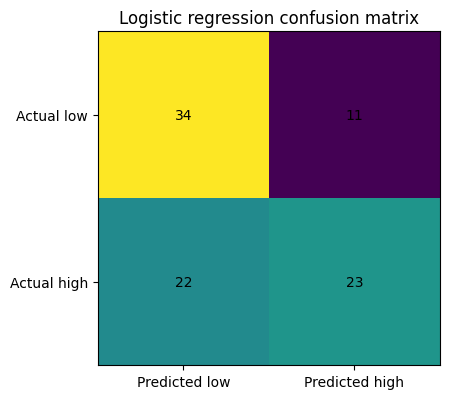

In [ ]:
# Visualize the confusion matrix to see where the classifier is right and wrong.
plt.figure(figsize=(4.6, 4.1))
plt.imshow(cm, aspect="auto")
plt.title("Logistic regression confusion matrix")
plt.xticks([0, 1], ["Predicted low", "Predicted high"])
plt.yticks([0, 1], ["Actual low", "Actual high"])

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        plt.text(col, row, str(cm[row, col]), ha="center", va="center")

plt.tight_layout()
plt.show()


### Interpretation
The confusion matrix shows more false negatives than false positives. That means the classifier is relatively conservative: it misses a meaningful share of truly high-engagement videos, even though it avoids over-labeling low-engagement videos as high.

# 8. Conclusion

# Conclusion

This final project makes three improvements from the midterm term project. First, we replace a potentially unbalanced collection design with an uploads-based **stratified category sample**, which makes cross-category comparisons much more defensible. Second, we use more than one dataset in a meaningful way by combining video metadata, the official category lookup, and sampled comments. Third, we turn the descriptive work into a simple but coherent modeling exercise using features that a manager can actually interpret.

For the target audience, the practical message is straightforward. Category should be treated as a planning unit rather than as background metadata. Format choices such as duration and title packaging appear to matter enough to deserve deliberate testing. Publish timing also looks like a controllable margin worth testing in a structured way. The models are intentionally simple, but they show that these engineered variables carry usable signal.

If there were more time, the best next step would be to add richer outcome variables from YouTube Analytics, especially watch time, retention, and audience geography. That would allow the analysis to move from simple exposure and engagement toward a fuller view of audience quality and content efficiency.


In [ ]:
conn.close()
